In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("results/results_qwen_main_2026-05-06_full.csv")


def _short_model_name(name: str) -> str:
    n = str(name).split("/")[-1]
    n = n.replace("-Instruct", "").replace("-Base", "")
    return n

df["guesser_label"] = df["guesser_model"].str.split("/").str[-1]
df["secret_label"]  = df["secret_model"].str.split("/").str[-1]
df["guesser_short"] = df["guesser_model"].apply(_short_model_name)
df["secret_short"]  = df["secret_model"].apply(_short_model_name)
df["config"] = df["mode"] + "\n" + df["guesser_label"] + " / " + df["secret_label"]



# Preferred metric: strict verified wins (fallback for older CSV schema)
if "num_verified_wins" in df.columns:
    df["avg_verified_win_score"] = df["num_verified_wins"] / df["num_games"]

print(f"{len(df)} run(s) loaded")
df


85 run(s) loaded


,run_id,seed,mode,guesser_model,secret_model,num_games,num_wins,judge_win_count,num_verified_wins,num_high_confidence,...,energy_per_game_wh,co2_g,co2_per_game_g,adjusted_co2_per_game_g,guesser_label,secret_label,guesser_short,secret_short,config,avg_verified_win_score
0,slurm-batch4401-seed1-4418,1,tool,Qwen/Qwen3-1.7B,Qwen/Qwen3-1.7B,100,87,87,68,64,...,NaN,0.0,NaN,NaN,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,tool\nQwen3-1.7B / Qwen3-1.7B,0.68
1,slurm-batch4401-seed2-4845,2,tool,Qwen/Qwen3-1.7B,Qwen/Qwen3-1.7B,100,82,82,64,61,...,NaN,0.0,NaN,NaN,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,tool\nQwen3-1.7B / Qwen3-1.7B,0.64
2,slurm-batch4401-seed3-5984,3,tool,Qwen/Qwen3-1.7B,Qwen/Qwen3-1.7B,100,85,85,65,64,...,NaN,0.0,NaN,NaN,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,tool\nQwen3-1.7B / Qwen3-1.7B,0.65
3,slurm-batch4401-seed4-6083,4,tool,Qwen/Qwen3-1.7B,Qwen/Qwen3-1.7B,100,85,85,63,59,...,NaN,0.0,NaN,NaN,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,tool\nQwen3-1.7B / Qwen3-1.7B,0.63
4,slurm-batch4401-seed5-6675,5,tool,Qwen/Qwen3-1.7B,Qwen/Qwen3-1.7B,100,84,84,68,66,...,NaN,0.0,NaN,NaN,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,Qwen3-1.7B,tool\nQwen3-1.7B / Qwen3-1.7B,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,slurm-batch4416-seed1-1244,1,tool,Qwen/Qwen3.5-9B,Qwen/Qwen3.5-9B,100,14,14,14,14,...,NaN,0.0,NaN,NaN,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,tool\nQwen3.5-9B / Qwen3.5-9B,0.14
81,slurm-batch4416-seed2-1374,2,tool,Qwen/Qwen3.5-9B,Qwen/Qwen3.5-9B,100,6,6,5,4,...,NaN,0.0,NaN,NaN,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,tool\nQwen3.5-9B / Qwen3.5-9B,0.05
82,slurm-batch4416-seed3-1428,3,tool,Qwen/Qwen3.5-9B,Qwen/Qwen3.5-9B,100,8,8,6,5,...,NaN,0.0,NaN,NaN,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,tool\nQwen3.5-9B / Qwen3.5-9B,0.06
83,slurm-batch4416-seed4-1433,4,tool,Qwen/Qwen3.5-9B,Qwen/Qwen3.5-9B,100,9,9,8,7,...,NaN,0.0,NaN,NaN,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,Qwen3.5-9B,tool\nQwen3.5-9B / Qwen3.5-9B,0.08


## 1 — Win rate by mode & model
Shows how often the guesser wins across different configurations. When multiple seeds exist, bars show the mean and error bars show standard deviation.

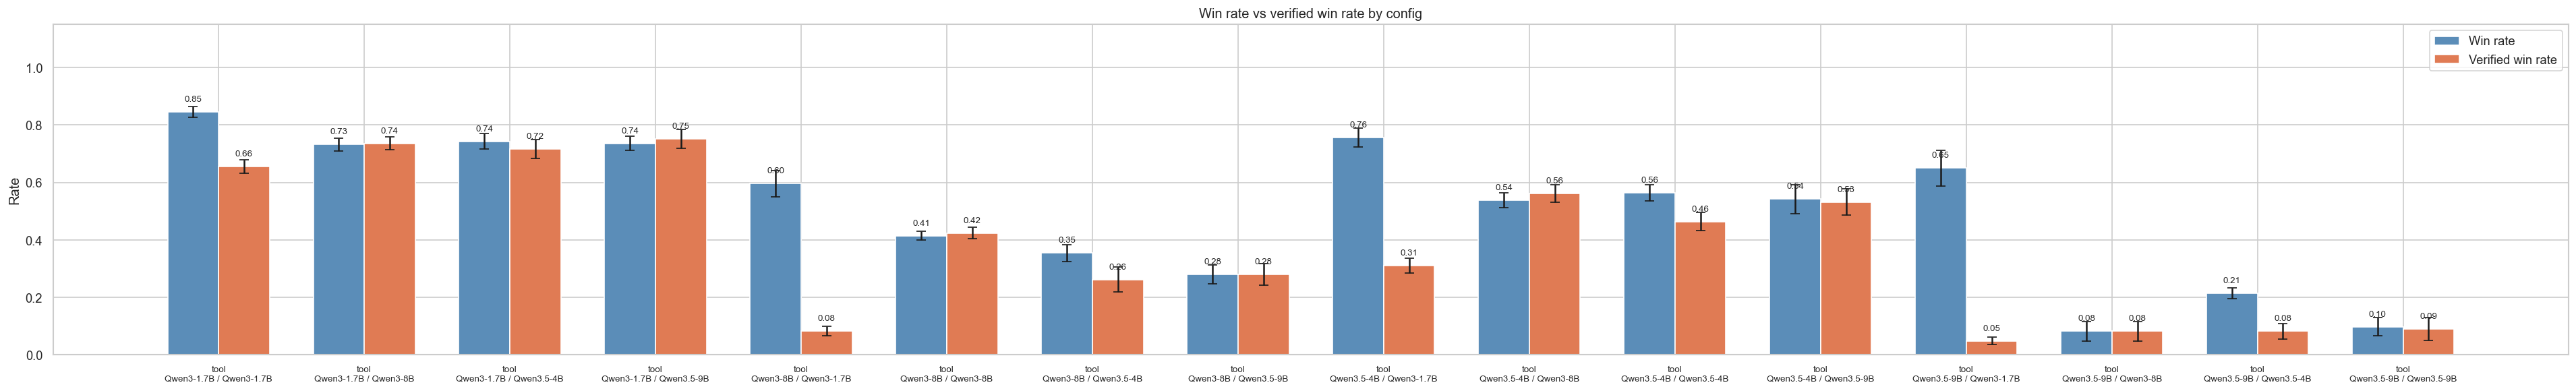

In [42]:
grouped = df.groupby("config")[["avg_win_score", "avg_verified_win_score"]].agg(["mean", "std"]).reset_index()
grouped.columns = ["config", "win_mean", "win_std", "verified_mean", "verified_std"]
grouped[["win_std", "verified_std"]] = grouped[["win_std", "verified_std"]].fillna(0)

x = np.arange(len(grouped))
width = 0.35
fig, ax = plt.subplots(figsize=(max(9, len(grouped) * 2.0), 5))

bars1 = ax.bar(x - width/2, grouped["win_mean"], width, yerr=grouped["win_std"],
               capsize=4, label="Win rate", color="#5b8db8", edgecolor="white")
bars2 = ax.bar(x + width/2, grouped["verified_mean"], width, yerr=grouped["verified_std"],
               capsize=4, label="Verified win rate", color="#e07b54", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(grouped["config"], fontsize=8)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(0)
    lbl.set_ha("center")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.15)
ax.set_title("Win rate vs verified win rate by config")
ax.legend()

for bar, val in zip(bars1, grouped["win_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, grouped["verified_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 1b — Secret keeper reliability
How well did the secret keeper model behave? `avg_secret_keeper_accuracy` measures how often it gave consistent answers. Leaked games are ones where the secret keeper revealed the answer in a YES/NO response. False correct games are ones where it said CORRECT but the guess didn't match the secret.

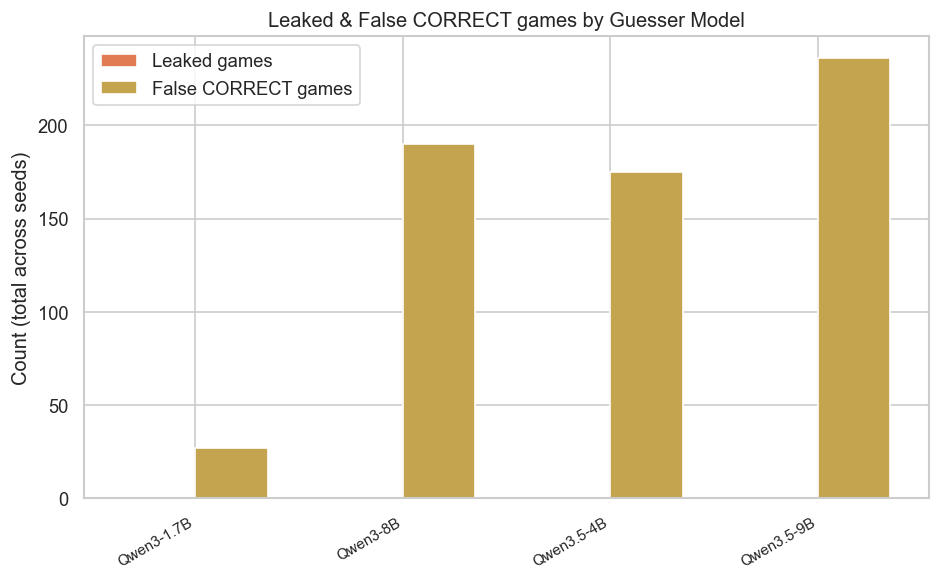

In [43]:
new_cols = {"num_leaked", "num_false_correct"}
if not new_cols.issubset(df.columns):
    print("Columns not found — re-run gather_results.py with new data.")
else:                                       
    sk = df.groupby("guesser_model").agg(
        leaked=("num_leaked", "sum"),
        false_correct=("num_false_correct", "sum"),                                                           
    ).reset_index()                     
    sk["guesser_model"] = sk["guesser_model"].str.replace("Qwen/", "", regex=False)                           
    sk = sk.sort_values("leaked", ascending=False)                                                            
                                            
    x = np.arange(len(sk))                                                                                    
    width = 0.35                                                                                              
                                                                                                            
    fig, ax = plt.subplots(figsize=(8, 5))                                                                    
    ax.bar(x - width/2, sk["leaked"],        width, label="Leaked games",        color="#e07b54",             
edgecolor="white")                          
    ax.bar(x + width/2, sk["false_correct"], width, label="False CORRECT games", color="#c4a44e",             
edgecolor="white")                          
    ax.set_xticks(x)                                                                                          
    ax.set_xticklabels(sk["guesser_model"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Count (total across seeds)")                                                               
    ax.set_title("Leaked & False CORRECT games by Guesser Model")
    ax.legend()                                                                                               
    plt.tight_layout()                                                                                        
    plt.show()

## 2 — Score breakdown per config
Compares all evaluation metrics side by side. Good for spotting whether a model is strong at one layer but weak at another.

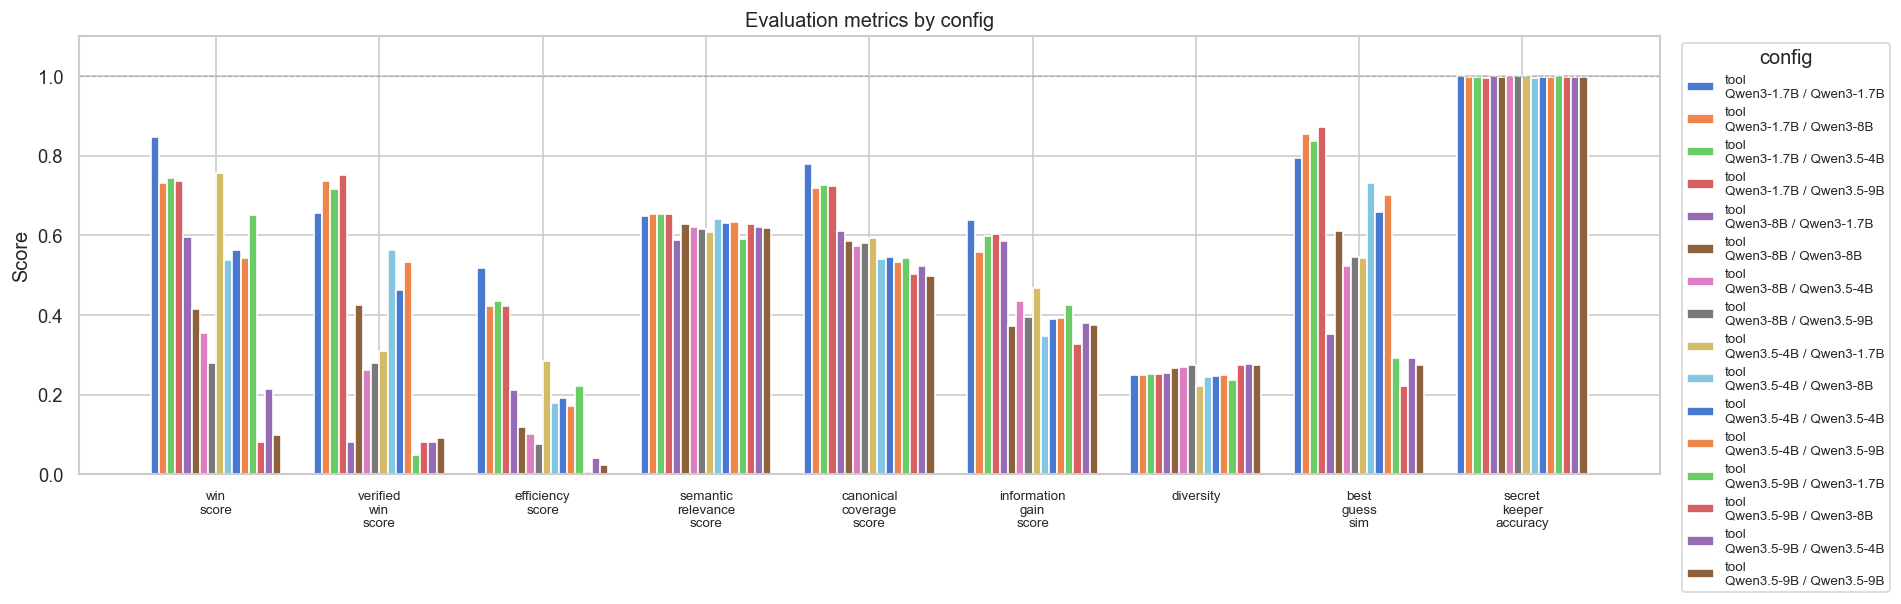

In [44]:
metrics = [
    "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
    "avg_semantic_relevance_score", "avg_canonical_coverage_score",
    "avg_information_gain_score", "avg_diversity",
    "avg_best_guess_sim", "avg_secret_keeper_accuracy",
]
# Only keep metrics that exist in this CSV (graceful for old data)
metrics = [m for m in metrics if m in df.columns]
labels = [m.replace("avg_", "").replace("_", "\n") for m in metrics]

mean_df = df.groupby("config")[metrics].mean()

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(metrics))
width = 0.8 / max(len(mean_df), 1)
colors = sns.color_palette("muted", len(mean_df))

for i, (config, row) in enumerate(mean_df.iterrows()):
    offset = (i - len(mean_df)/2 + 0.5) * width
    ax.bar(x + offset, row[metrics], width=width, label=config, color=colors[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Evaluation metrics by config")
ax.legend(title="config", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()


## 3 — Seed variance (stability across runs)
When you have multiple seeds per config, this shows how stable the results are. High variance = the model is sensitive to random seed.

/var/folders/7q/31p4y51963s54pdw7y8fcz0r0000gn/T/ipykernel_14707/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/7q/31p4y51963s54pdw7y8fcz0r0000gn/T/ipykernel_14707/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/7q/31p4y51963s54pdw7y8fcz0r0000gn/T/ipykernel_14707/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_

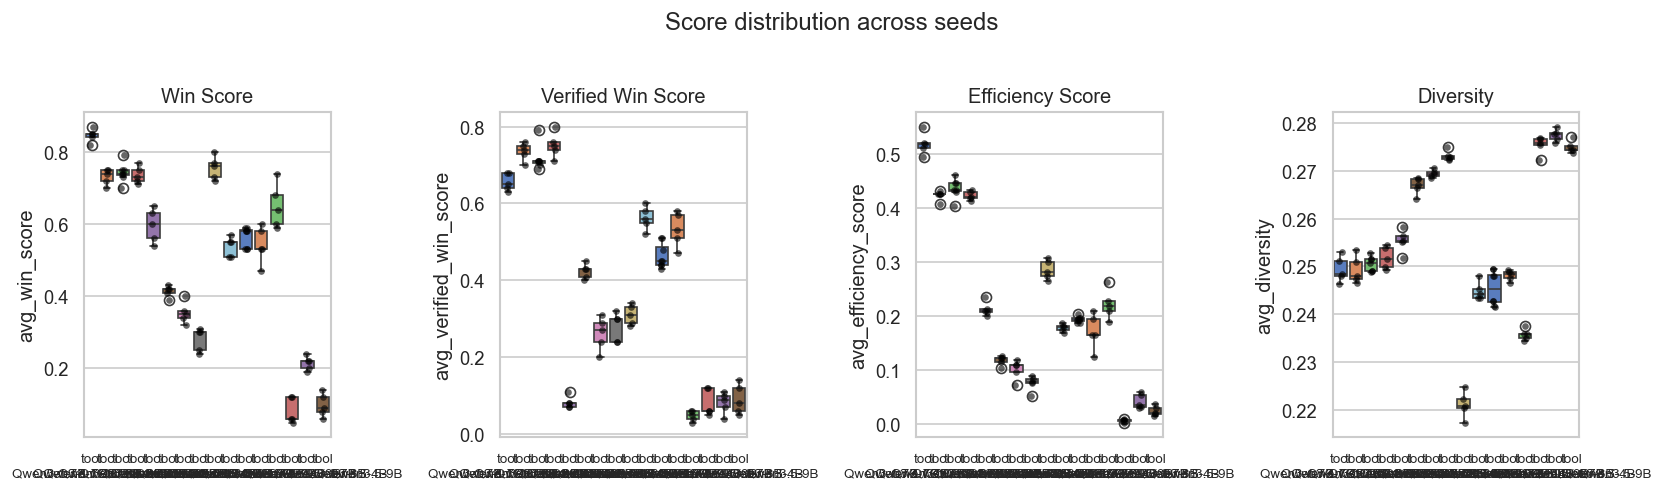

In [45]:
seed_metrics = ["avg_win_score", "avg_verified_win_score", "avg_efficiency_score", "avg_diversity"]
seed_metrics = [m for m in seed_metrics if m in df.columns]

configs_with_seeds = df.groupby("config").filter(lambda x: len(x) > 1)

if configs_with_seeds.empty:
    print("Need multiple seeds per config to show variance. Run submit_bulk_seeds.sh first.")
else:
    fig, axes = plt.subplots(1, len(seed_metrics), figsize=(max(14, len(seed_metrics) * 3.5), 4), sharey=False)
    if len(seed_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, seed_metrics):
        sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
        sns.stripplot(data=configs_with_seeds, x="config", y=metric, ax=ax,
                      color="black", size=4, alpha=0.6, jitter=True)
        ax.set_title(metric.replace("avg_", "").replace("_", " ").title())
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)
    plt.suptitle("Score distribution across seeds", y=1.02)
    plt.tight_layout()
    plt.show()


## 4 — Carbon footprint
CO2 per game and total energy by config. Useful for comparing the environmental cost of larger vs smaller models.

In [46]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()
carbon


,config,co2_per_game_g,energy_per_game_wh
0,tool\nQwen3-1.7B / Qwen3-1.7B,NaN,NaN
1,tool\nQwen3-1.7B / Qwen3-8B,NaN,NaN
2,tool\nQwen3-1.7B / Qwen3.5-4B,NaN,NaN
3,tool\nQwen3-1.7B / Qwen3.5-9B,NaN,NaN
4,tool\nQwen3-8B / Qwen3-1.7B,NaN,NaN
5,tool\nQwen3-8B / Qwen3-8B,NaN,NaN
6,tool\nQwen3-8B / Qwen3.5-4B,NaN,NaN
7,tool\nQwen3-8B / Qwen3.5-9B,NaN,NaN
8,tool\nQwen3.5-4B / Qwen3-1.7B,NaN,NaN
9,tool\nQwen3.5-4B / Qwen3-8B,NaN,NaN


In [47]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()

if carbon[["co2_per_game_g", "energy_per_game_wh"]].isna().all().all():
    print("No valid carbon values (all NaN); skipping carbon bar plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, col, label, color in zip(
        axes,
        ["co2_per_game_g", "energy_per_game_wh"],
        ["CO2 per game (g)", "Energy per game (Wh)"],
        ["#e07b54", "#5b8db8"],
    ):
        tmp = carbon.dropna(subset=[col]).copy()
        if tmp.empty:
            ax.set_title(label)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            continue

        bars = ax.bar(tmp["config"], tmp[col], color=color, edgecolor="white")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.tick_params(axis="x", labelsize=7)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(0)
            lbl.set_ha("center")

        ymax = float(tmp[col].max()) if len(tmp[col]) else 0.0
        offset = (ymax * 0.01) if ymax > 0 else 0.01
        for bar, val in zip(bars, tmp[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.suptitle("Carbon footprint by config")
    plt.tight_layout()
    plt.show()


No valid carbon values (all NaN); skipping carbon bar plots.


## 5 — Win rate vs CO₂ (efficiency frontier)
Is the better-performing model worth the extra carbon cost? Points in the top-left are ideal (high win rate, low CO₂).

In [48]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

scatter = df.groupby("config").agg(
    win=("avg_win_score", "mean"),
    verified_win=("avg_verified_win_score", "mean"),
    co2=("co2_per_game_g", "mean"),
).reset_index()

scatter = scatter.dropna(subset=["co2", "win", "verified_win"])
if scatter.empty:
    print("No valid carbon values (co2 is NaN), skipping carbon scatter plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = sns.color_palette("muted", len(scatter))

    for ax, y_col, title in zip(
        axes,
        ["win", "verified_win"],
        ["Win rate vs carbon cost", "Verified win rate vs carbon cost"],
    ):
        for i, row in scatter.iterrows():
            ax.scatter(row["co2"], row[y_col], s=120, color=colors[i], zorder=3)
            ax.annotate(row["config"], (row["co2"], row[y_col]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)
        ax.set_xlabel("CO2 per game (g)")
        ax.set_ylabel(y_col.replace("_", " ").title())
        ax.set_title(title)
        ax.set_xlim(left=0)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)

    plt.tight_layout()
    plt.show()


No valid carbon values (co2 is NaN), skipping carbon scatter plots.


## 6 — Guesser × Secret keeper win rate heatmap
Which (guesser, secret keeper) model pairings lead to the highest win rates? Each cell shows the mean win rate for that combination.

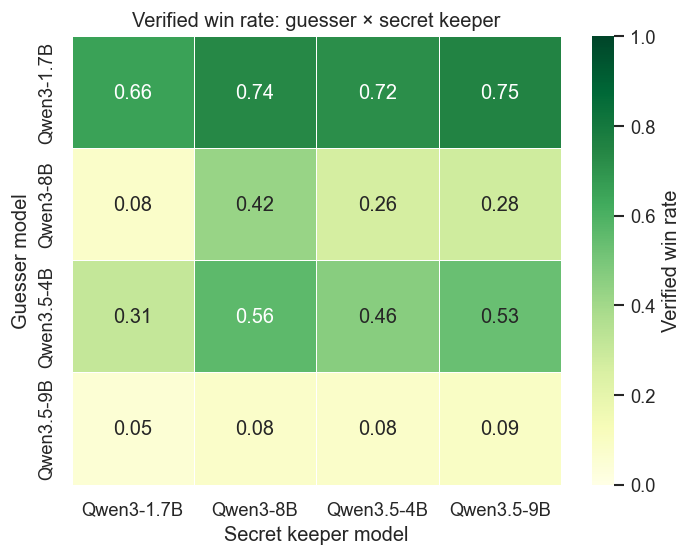

In [49]:
pivot = df.groupby(["guesser_short", "secret_short"])["avg_verified_win_score"].mean().unstack()

if pivot.shape[0] < 2 or pivot.shape[1] < 2:
    print("Need multiple guesser and secret keeper model variants to build this heatmap.")
else:
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.5), max(4, pivot.shape[0] * 1.2)))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper model")
    ax.set_ylabel("Guesser model")
    ax.set_title("Verified win rate: guesser × secret keeper")
    plt.tight_layout()
    plt.show()


## 6b — Secret keeper accuracy heatmap
Same guesser × secret keeper grid, but showing `avg_secret_keeper_accuracy` instead of win rate. Helps separate "the guesser was bad" from "the secret keeper was unreliable".

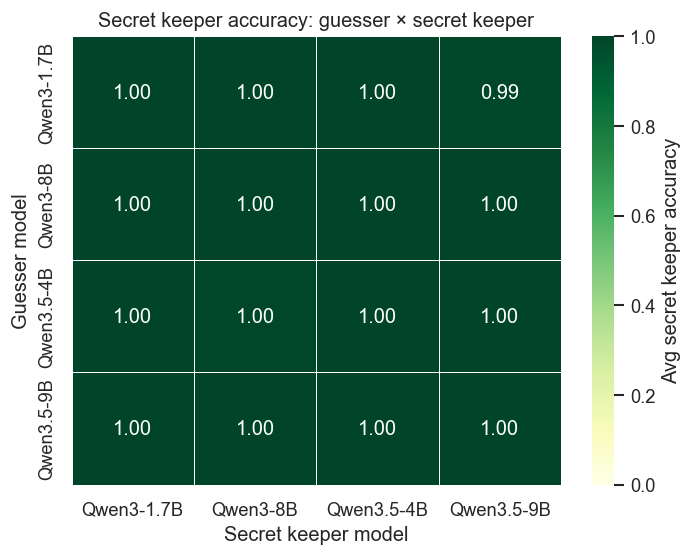

In [50]:
if "avg_secret_keeper_accuracy" not in df.columns:
    print("avg_secret_keeper_accuracy not found — re-run gather_results.py with new data.")
else:
    sk_pivot = df.groupby(["guesser_label", "secret_label"])["avg_secret_keeper_accuracy"].mean().unstack()

    if sk_pivot.shape[0] < 2 or sk_pivot.shape[1] < 2:
        print("Need multiple guesser and secret keeper model variants to build this heatmap.")
    else:
        fig, ax = plt.subplots(figsize=(max(6, sk_pivot.shape[1] * 1.5), max(4, sk_pivot.shape[0] * 1.2)))
        sns.heatmap(
            sk_pivot, annot=True, fmt=".2f", cmap="YlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Avg secret keeper accuracy"},
        )
        ax.set_xlabel("Secret keeper model")
        ax.set_ylabel("Guesser model")
        ax.set_title("Secret keeper accuracy: guesser × secret keeper")
        plt.tight_layout()
        plt.show()


## 7 — Metric correlation heatmap
Which metrics tend to move together? Helps understand whether the evaluation layers are measuring different things or overlapping.

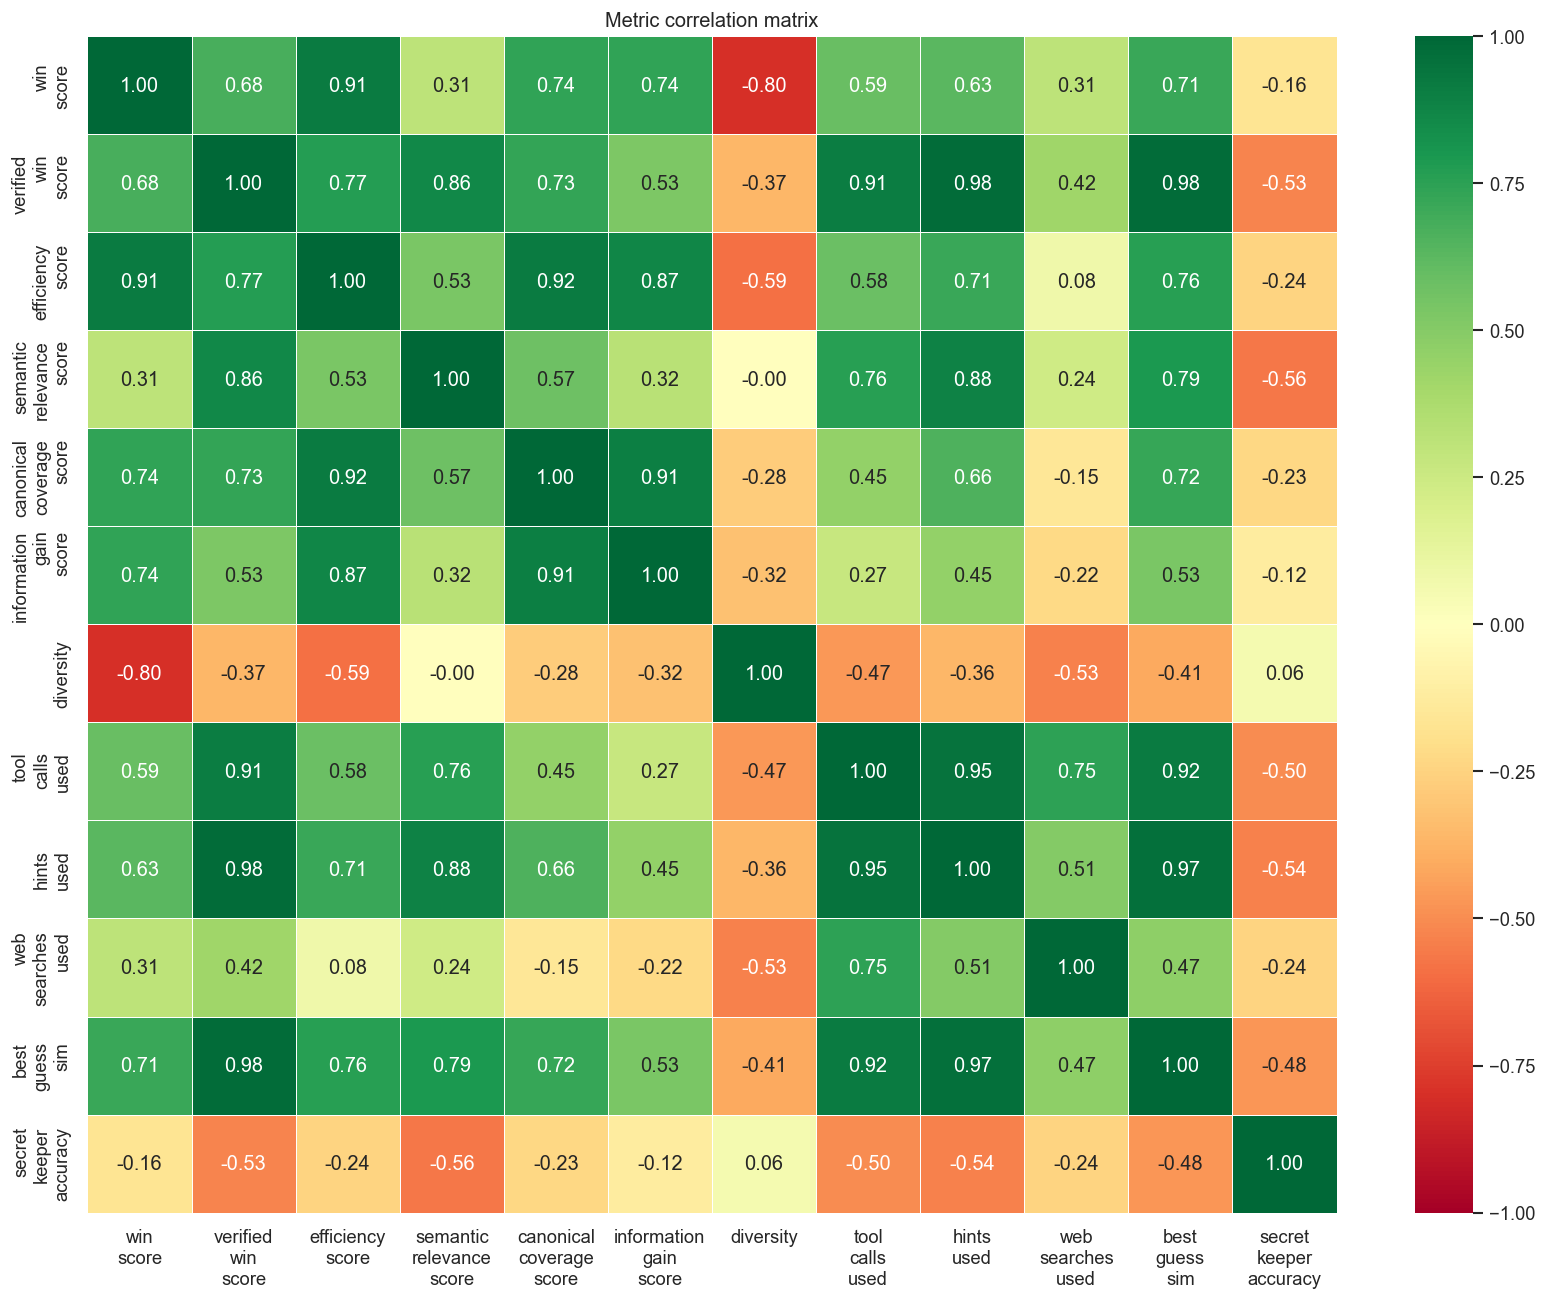

In [51]:
if len(df) < 3:
    print("Need at least 3 runs to compute meaningful correlations.")
else:
    corr_cols = [
        "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
        "avg_semantic_relevance_score", "avg_canonical_coverage_score",
        "avg_information_gain_score", "avg_diversity",
        "avg_tool_calls_used", "avg_hints_used", "avg_web_searches_used",
        "avg_best_guess_sim", "avg_secret_keeper_accuracy",
    ]
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr = df[corr_cols].corr()
    short = [c.replace("avg_", "").replace("_", "\n") for c in corr_cols]

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Metric correlation matrix")
    plt.tight_layout()
    plt.show()


## 8 — Quantization comparison heatmaps
For runs where the same model family is used for both guesser and secret keeper but with different quantizations (e.g. 4bit, 8bit, base), each cell shows the mean verified win rate for that (guesser quant × secret quant) pairing. One heatmap per model family.

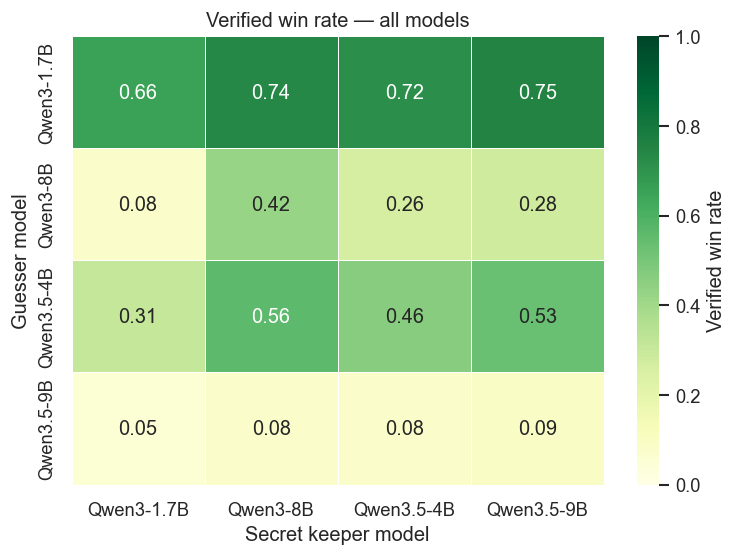

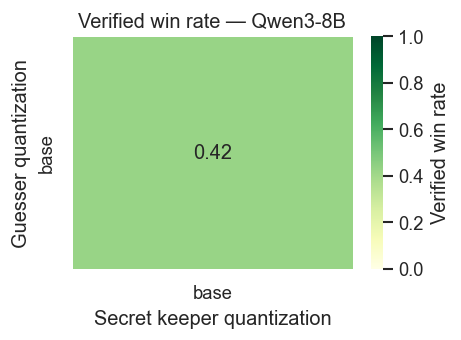

In [52]:
# ── Quantization config — fill in your model IDs here ───────────────────────
# Each key is a model family name (used as the heatmap title).
# Each value maps quantization label → exact model ID used in config.py.
# Add as many families and quant levels as you like.

QUANT_FAMILIES = {
    "Qwen3-8B": {
        "base": "Qwen/Qwen3-8B",
        "4bit": "your-org/Qwen3-8B-4bit",   # replace with actual model IDs
        "8bit": "your-org/Qwen3-8B-8bit",
    },
    # "Llama-3-8B": {
    #     "base": "meta-llama/Meta-Llama-3-8B",
    #     "4bit": "your-org/Llama-3-8B-4bit",
    # },
}

# ─────────────────────────────────────────────────────────────────────────────

# Overall model-family heatmap (uses guesser_label / secret_label from setup cell)
overall_pivot = (
    df.groupby(["guesser_label", "secret_label"])["avg_verified_win_score"]
    .mean()
    .unstack()
)

if overall_pivot.shape[0] >= 1 and overall_pivot.shape[1] >= 1:
    fig, ax = plt.subplots(
        figsize=(max(5, overall_pivot.shape[1] * 1.6),
                 max(3, overall_pivot.shape[0] * 1.2))
    )
    sns.heatmap(
        overall_pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper model")
    ax.set_ylabel("Guesser model")
    ax.set_title("Verified win rate — all models")
    plt.tight_layout()
    plt.show()

# Per-family quantization heatmaps
for family_name, quant_map in QUANT_FAMILIES.items():
    # Invert: model_id → quant label
    id_to_quant = {v: k for k, v in quant_map.items()}

    sub = df[
        df["guesser_model"].isin(id_to_quant) &
        df["secret_model"].isin(id_to_quant)
    ].copy()

    if sub.empty:
        print(f"[{family_name}] No matching runs found — check model IDs in QUANT_FAMILIES.")
        continue

    sub["guesser_quant"] = sub["guesser_model"].map(id_to_quant)
    sub["secret_quant"]  = sub["secret_model"].map(id_to_quant)

    pivot = (
        sub.groupby(["guesser_quant", "secret_quant"])["avg_verified_win_score"]
        .mean()
        .unstack()
    )

    # Preserve order as defined in QUANT_FAMILIES
    quant_order = list(quant_map.keys())
    row_order = [q for q in quant_order if q in pivot.index]
    col_order = [q for q in quant_order if q in pivot.columns]
    pivot = pivot.reindex(index=row_order, columns=col_order)

    fig, ax = plt.subplots(
        figsize=(max(4, len(col_order) * 1.6), max(3, len(row_order) * 1.2))
    )
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper quantization")
    ax.set_ylabel("Guesser quantization")
    ax.set_title(f"Verified win rate — {family_name}")
    plt.tight_layout()
    plt.show()


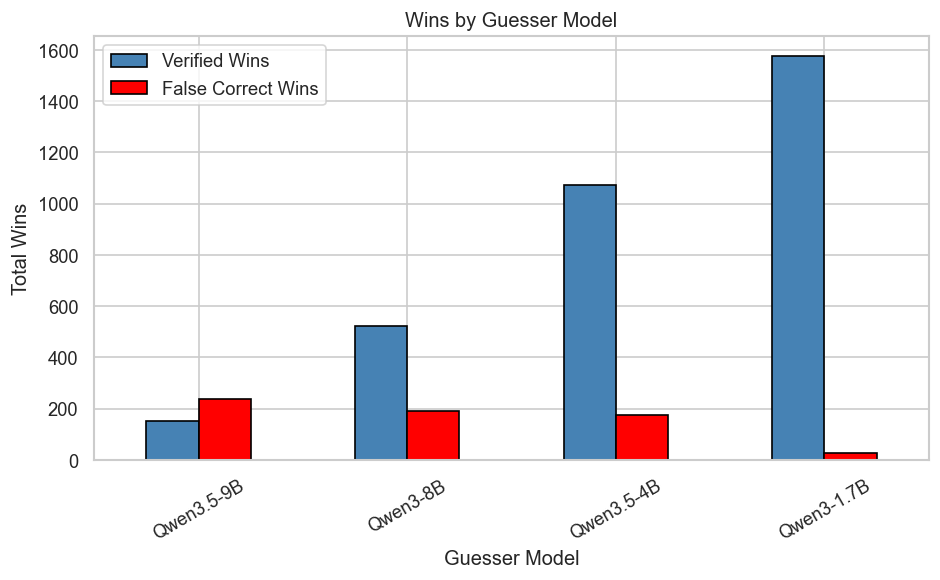

In [53]:
combined = df.groupby("guesser_model")[["num_verified_wins", "num_false_correct"]].sum()                               
combined.index = combined.index.str.replace("Qwen/", "", regex=False)
combined = combined.sort_values("num_false_correct", ascending=False)                                                  
combined.columns = ["Verified Wins", "False Correct Wins"]                                                            
                                            
fig, ax = plt.subplots(figsize=(8, 5))                                                                        
combined.plot(kind="bar", ax=ax, color=["steelblue", "red"], edgecolor="black")
ax.set_title("Wins by Guesser Model")                                                                         
ax.set_xlabel("Guesser Model")          
ax.set_ylabel("Total Wins")                                                                                   
ax.tick_params(axis="x", rotation=30)                                                                         
plt.tight_layout()                          
plt.show()  